**CROP PREDICTION**

**This project focuses on building a data-driven crop recommendation system that helps farmers make informed decisions by predicting the most suitable crop type based on features**

**Dataset Description**
This dataset is a multi-class classification dataset used for predicting the most suitable crop based on soil and environmental conditions.
File Name : Crop_recommendation (1).csv
Task Type : Multi-class Classification
Domain : Agriculture / Crop Recommendation System
**Specific Objectives**
!! Data Exploration & Preprocessing
!! Exploratory Data Analysis (EDA)
!! Model Development
!! Model Evaluation
**Why This Matters**
!!Helps increase crop yield by recommending optimal crops
!!Reduces resource waste (water, fertilizer, labor)
!!Promotes smart and precision farming




# importing liberaries 

In [1]:
import pandas as pd
import numpy as np
import warnings
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore")


# importing the csv file 

In [2]:
dfr=pd.read_csv("C:/Users/HP ZBOOK 15 G3/Downloads/Crop_recommendation (1).csv")
dfr.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# making the decimals values with two decimals 

In [3]:
df=dfr.round(1)

In [4]:
df.shape

(2200, 8)

In [5]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.9,82.0,6.5,202.9,rice
1,85,58,41,21.8,80.3,7.0,226.7,rice
2,60,55,44,23.0,82.3,7.8,264.0,rice
3,74,35,40,26.5,80.2,7.0,242.9,rice
4,78,42,42,20.1,81.6,7.6,262.7,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.8,66.4,6.8,177.8,coffee
2196,99,15,27,27.4,56.6,6.1,127.9,coffee
2197,118,33,30,24.1,67.2,6.4,173.3,coffee
2198,117,32,34,26.3,52.1,6.8,127.2,coffee


 # getting the information of the dataset 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


# checking for null values 

In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

# checking the count of target column 

In [8]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

# visualizing the distribution of crop 

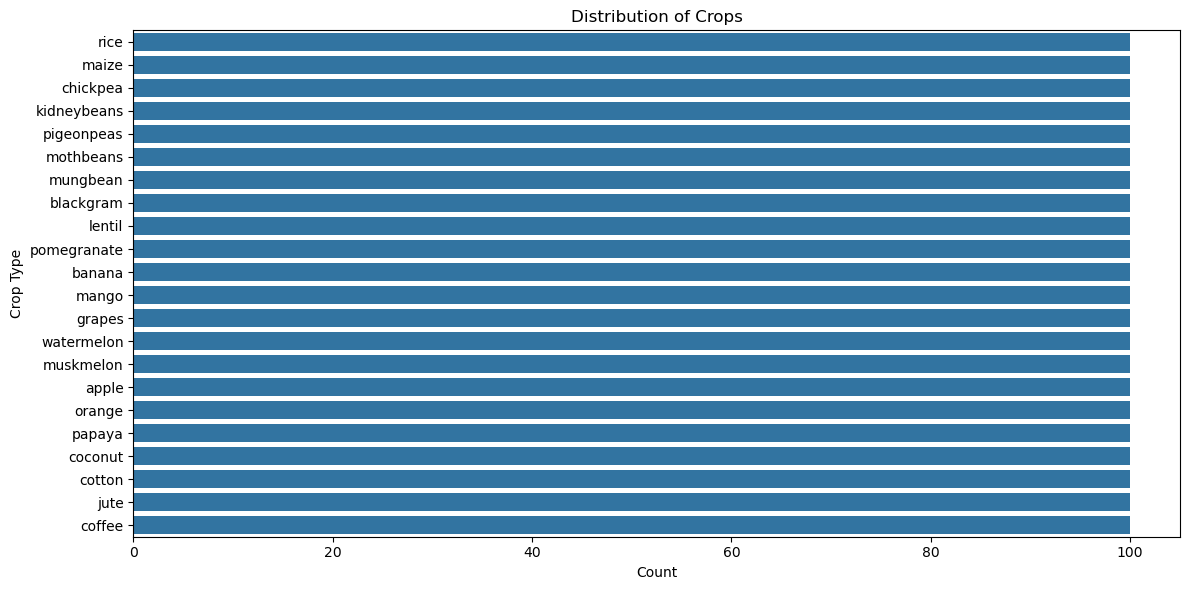

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label')
plt.title('Distribution of Crops')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.tight_layout()
plt.show()

# visualizing the nitrogen 

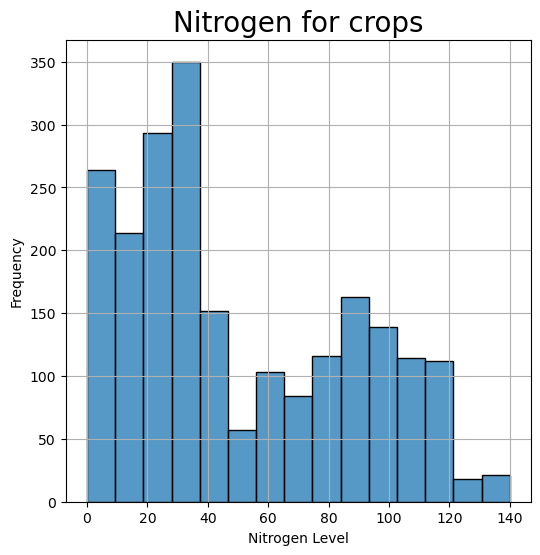

In [10]:
plt.figure(figsize=(6,6))
sns.histplot(x='N', data=df)
plt.title("Nitrogen for crops", fontsize=20)
plt.xlabel("Nitrogen Level")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# visualizing the potassium 

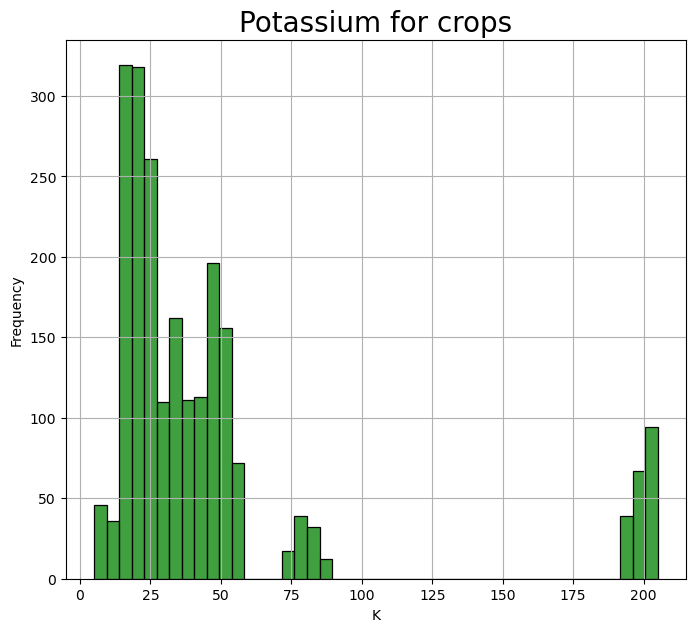

In [11]:
plt.figure(figsize=(8,7))
sns.histplot(x='K',data=df,color="green")
plt.title("Potassium for crops",{'fontsize':20})
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# visualizing the phosphorus

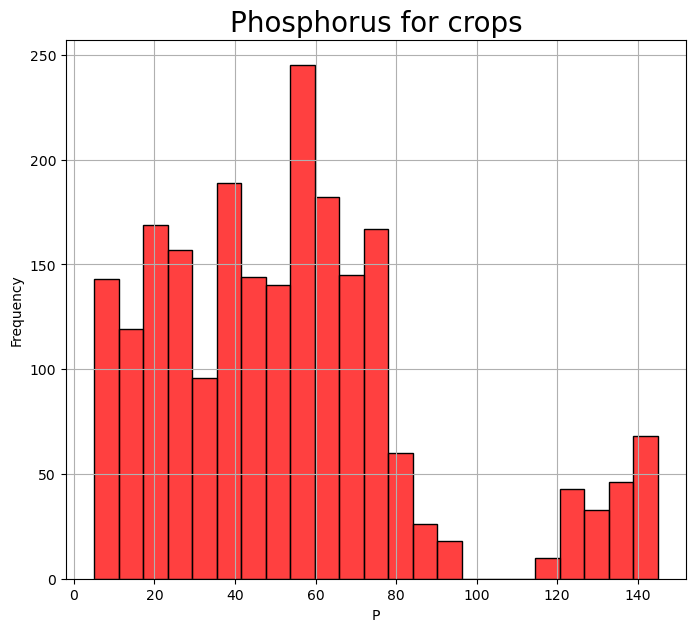

In [12]:
plt.figure(figsize=(8,7))
sns.histplot(x='P',data=df,color="red");
plt.title("Phosphorus for crops",{'fontsize':20});
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# visualizing the correlation throught heatmap 

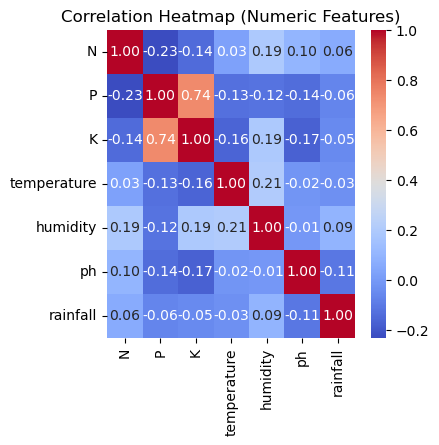

In [13]:
plt.figure(figsize=(4,4))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# assigning the feature and target variables

In [204]:
X=df.iloc[:,:-1]
y=df['label']

# converting traning and testing data

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# normilizing the variable 

In [206]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# implementing the logistic regression

In [207]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000)

# training the model

In [208]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, multi_class='multinomial')

# make prediction

In [209]:
y_pred = model.predict(X_test_scaled)

# printing the accuracy and classification reports

In [210]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 96.36%
Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00  

# getting confusion matrix

In [211]:
cm=confusion_matrix(y_test, y_pred)

# plotting throught heatmap

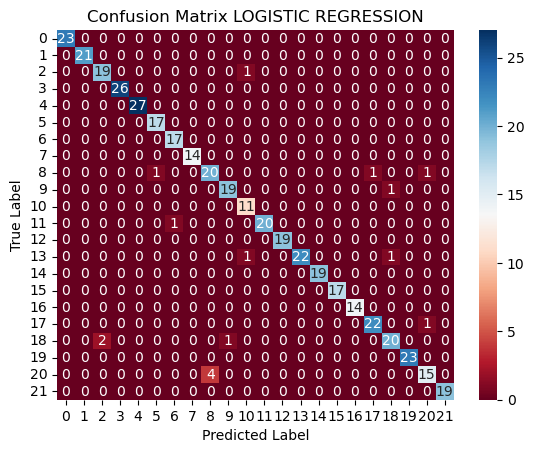

In [298]:
sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu")  
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix LOGISTIC REGRESSION")
plt.show()


# overall train accuracy

In [213]:
model.score(X_train_scaled,y_train)

0.9789772727272728

# overall testing accuracy

In [214]:
model.score(X_test_scaled,y_test)

0.9636363636363636

# sample example output 

In [215]:
example = np.array([[107,34,32,26.8,66.4,6.8,177.8]]) 
example_scaled = scaler.transform(example)
predicted_crop = model.predict(example_scaled)
print(f"Predicted Crop: {predicted_crop[0]}")

Predicted Crop: coffee


# implementing the neural networks

In [259]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall

In [217]:
X1=df.iloc[:,:-1]
Y1=df['label']

# encoding the target variable

In [218]:
le = LabelEncoder()
Y2 = le.fit_transform(Y1)

In [219]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X1)

In [220]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X_scaled, Y2, test_size=0.2, random_state=42)

# converting the target variable to categorical

In [221]:
y_train_cat = to_categorical(y1_train)
y_test_cat = to_categorical(y1_test)


# creating the neural layers

In [270]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X1_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(len(le.classes_), activation='softmax') 
])

# compiling the model

In [271]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

In [272]:
history = model.fit(X1_train, y_train_cat, epochs=50,batch_size=32,validation_split=0.1,verbose=1)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0486 - loss: 3.0156 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 2.6424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4143 - loss: 2.5185 - precision: 0.1569 - recall: 2.4396e-04 - val_accuracy: 0.5057 - val_loss: 1.9764 - val_precision: 1.0000 - val_recall: 0.0227
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6373 - loss: 1.8165 - precision: 0.9935 - recall: 0.0485 - val_accuracy: 0.7216 - val_loss: 1.3224 - val_precision: 1.0000 - val_recall: 0.1989
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7620 - loss: 1.2003 - precision: 0.9854 - recall: 0.1935 - val_accuracy: 0.8182 - val_loss: 0.8445 - val_precision: 1.0000 - val_recall: 0.5284
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8685 - loss: 0.7324 - precision: 0.9757 - recall: 0.5656 - val_accuracy: 0.8864 - v

In [279]:

test_loss,test_acc, test_precision, test_recall = model.evaluate(X1_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")


Test Accuracy: 0.98
Test Precision: 0.98
Test Recall: 0.98


# creating the random forest

In [228]:
from sklearn.ensemble import RandomForestClassifier


In [249]:
X2=df.iloc[:,:-1]
Y2=df['label']

In [250]:
le = LabelEncoder()
y_encoded = le.fit_transform(Y2)

In [251]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y_encoded, test_size=0.2, random_state=42)

In [252]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X2_train, y2_train)

RandomForestClassifier(random_state=42)

In [253]:
y_predt = rf.predict(X2_test)


In [258]:
print("Training Accuracy:", rf.score(X2_train, y2_train))
print("Test Accuracy:", rf.score(X2_test, y2_test))

Training Accuracy: 1.0
Test Accuracy: 0.9931818181818182


In [254]:
print(f"Accuracy: {accuracy_score(y2_test, y_predt):.2f}")
print("\nClassification Report:")
print(classification_report(y2_test, y_predt))

Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.0

In [255]:
cmtx=confusion_matrix(y2_test, y_predt)

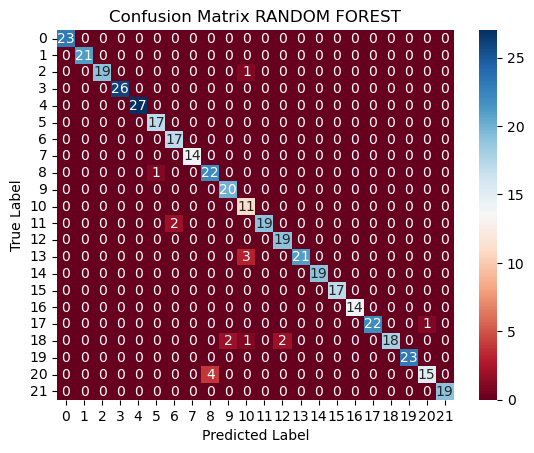

In [297]:
sns.heatmap(cmtx, annot=True, fmt="d", cmap="RdBu")  
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix RANDOM FOREST")
plt.show()


# implementing the KNN

In [280]:
from sklearn.neighbors import KNeighborsClassifier

In [281]:
X3=df.iloc[:,:-1]
Y3=df['label']

In [283]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, Y3, test_size=0.2, random_state=42)


In [286]:
scaler = StandardScaler()
X1_train_scaled = scaler.fit_transform(X3_train)
X1_test_scaled = scaler.transform(X3_test)

In [287]:
knn = KNeighborsClassifier(n_neighbors=5)  
knn.fit(X1_train_scaled, y3_train)

KNeighborsClassifier()

In [288]:
yk_pred = knn.predict(X_test_scaled)


In [294]:
print(f"Accuracy: {accuracy_score(y3_test, yk_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y3_test, yk_pred))




Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.89      1.00      0.94        17
      grapes       1.00      1.00      1.00        14
        jute       0.85      0.96      0.90        23
 kidneybeans       0.91      1.00      0.95        20
      lentil       0.69      1.00      0.81        11
       maize       1.00      0.90      0.95        21
       mango       0.90      1.00      0.95        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.0

In [293]:
cmv=(confusion_matrix(y3_test, yk_pred))

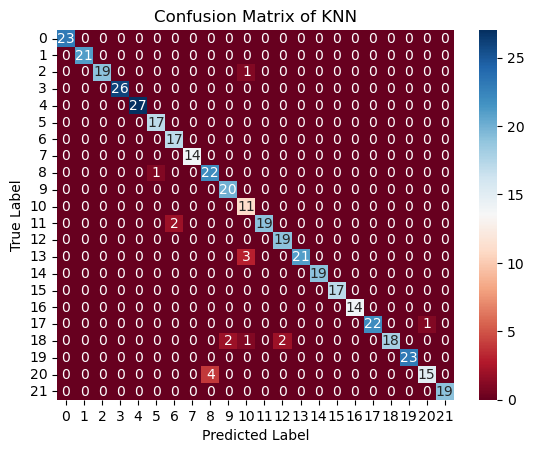

In [296]:
sns.heatmap(cmv, annot=True, fmt="d", cmap="RdBu")  
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of KNN")
plt.show()
